In [2]:
#import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#load mercedes file
filepath=r"C:\Users\Dell\Desktop\EDGELINE\PersonalProject\mercedes_benz_listings_cleaned.csv"
df=pd.read_csv(filepath)

In [4]:
#preview data
df.head()
#pd.reset_option('All')

,Vehicle_Name,Year,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Mileage_Category,Price_USD,Price_Category,Price_Per_Mile
0,2025 Mercedes-Benz AMG S 63 E 4MATIC,2025,1,AMG S 63,S 63,Other,1,1,9860,Low (< 20K),151900,Luxury (> $70K),15.405680
1,2025 Mercedes-Benz GLE 580 4MATIC,2025,1,GLE,E 580,SUV,0,1,3154,Low (< 20K),82975,Luxury (> $70K),26.307863
2,2025 Mercedes-Benz GLS 450 4MATIC,2025,1,GLS,S 450,SUV,0,1,15496,Low (< 20K),75500,Luxury (> $70K),4.872225
3,2025 Mercedes-Benz GLE 450e 4MATIC,2025,1,GLE,E 450,SUV,0,1,9303,Low (< 20K),67996,Premium ($40K-$70K),7.309040
4,2025 Mercedes-Benz GLE 450e 4MATIC,2025,1,GLE,E 450,SUV,0,1,17259,Low (< 20K),63928,Premium ($40K-$70K),3.704038


In [5]:
body_type_category=df.groupby(by='Body_Type', sort=False)['Mileage_Miles'].agg(['sum']).round(0).sort_values(by=['sum'],ascending=False)
body_type_category

,sum
Body_Type,
SUV,2172471
Sedan,1683502
Other,682528
Van/Commercial,314172
Electric SUV/Sedan,126284
Coupe,112037
Sports/Roadster,42109


In [4]:
df.describe()

,Year,Vehicle_Age,Is_AMG,Is_4MATIC,Mileage_Miles,Price_USD,Price_Per_Mile
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,2020.555556,5.444444,0.138889,0.685185,47528.731481,40310.314815,3.236109
std,3.816671,3.816671,0.347443,0.466607,33832.988723,28047.141525,8.865698
min,2005.000000,1.000000,0.000000,0.000000,628.000000,6420.000000,0.051743
25%,2019.000000,3.000000,0.000000,0.000000,19769.000000,20603.500000,0.332010
50%,2022.000000,4.000000,0.000000,1.000000,42701.500000,33499.000000,0.932418
75%,2023.000000,7.000000,0.000000,1.000000,70671.250000,50243.500000,2.367580
max,2025.000000,21.000000,1.000000,1.000000,186500.000000,169995.000000,82.799363


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Vehicle_Name      108 non-null    object 
 1   Year              108 non-null    int64  
 2   Vehicle_Age       108 non-null    int64  
 3   Model_Series      108 non-null    object 
 4   Trim_Level        108 non-null    object 
 5   Body_Type         108 non-null    object 
 6   Is_AMG            108 non-null    int64  
 7   Is_4MATIC         108 non-null    int64  
 8   Mileage_Miles     108 non-null    int64  
 9   Mileage_Category  108 non-null    object 
 10  Price_USD         108 non-null    int64  
 11  Price_Category    108 non-null    object 
 12  Price_Per_Mile    108 non-null    float64
dtypes: float64(1), int64(6), object(6)
memory usage: 11.1+ KB


df_copy=df.copy()
df_copy

In [6]:
#check for nulls
for cols in df.columns:
    pct=np.mean(df[cols].isnull())
    print('{} - {}'.format(cols,pct *100))


Vehicle_Name - 0.0
Year - 0.0
Vehicle_Age - 0.0
Model_Series - 0.0
Trim_Level - 0.0
Body_Type - 0.0
Is_AMG - 0.0
Is_4MATIC - 0.0
Mileage_Miles - 0.0
Mileage_Category - 0.0
Price_USD - 0.0
Price_Category - 0.0
Price_Per_Mile - 0.0


#remove duplicates in vehicle_Name
df.drop_duplicates(subset='Vehicle_Name',inplace=True)
df.info()



In [5]:
#set vehicle name as table index
df.set_index(['Vehicle_Name'],inplace=True)
df


,Year,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Mileage_Category,Price_USD,Price_Category,Price_Per_Mile
Vehicle_Name,,,,,,,,,,,,
2025 Mercedes-Benz AMG S 63 E 4MATIC,2025,1,AMG S 63,S 63,Other,1,1,9860,Low (< 20K),151900,Luxury (> $70K),15.405680
2025 Mercedes-Benz GLE 580 4MATIC,2025,1,GLE,E 580,SUV,0,1,3154,Low (< 20K),82975,Luxury (> $70K),26.307863
2025 Mercedes-Benz GLS 450 4MATIC,2025,1,GLS,S 450,SUV,0,1,15496,Low (< 20K),75500,Luxury (> $70K),4.872225
2025 Mercedes-Benz GLE 450e 4MATIC,2025,1,GLE,E 450,SUV,0,1,9303,Low (< 20K),67996,Premium ($40K-$70K),7.309040
2025 Mercedes-Benz GLE 450e 4MATIC,2025,1,GLE,E 450,SUV,0,1,17259,Low (< 20K),63928,Premium ($40K-$70K),3.704038
...,...,...,...,...,...,...,...,...,...,...,...,...
2014 Mercedes-Benz E-Class E 250 BlueTEC 4MATIC,2014,12,E-Class,E 250,Sedan,0,1,186500,Very High (> 100K),9650,Budget (< $20K),0.051743
2013 Mercedes-Benz GLK-Class GLK 350 4MATIC,2013,13,GLK-Class,GLK 350,Other,0,1,131643,Very High (> 100K),11980,Budget (< $20K),0.091004
2012 Mercedes-Benz M-Class ML 350 4MATIC,2012,14,M-Class,Standard,SUV,0,1,118174,Very High (> 100K),11498,Budget (< $20K),0.097297


In [6]:
#sort table by Price_USD
df.sort_values(by='Price_USD',ascending=False,inplace=True)
#2021 Mercedes-Benz AMG G 63 Base has the highest cost
df

,Year,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Mileage_Category,Price_USD,Price_Category,Price_Per_Mile
Vehicle_Name,,,,,,,,,,,,
2021 Mercedes-Benz AMG G 63 Base,2021,5,AMG G 63,AMG G 63,Other,1,0,9938,Low (< 20K),169995,Luxury (> $70K),17.105554
2025 Mercedes-Benz AMG S 63 E 4MATIC,2025,1,AMG S 63,S 63,Other,1,1,9860,Low (< 20K),151900,Luxury (> $70K),15.405680
2024 Mercedes-Benz AMG GT 55 Base,2024,2,AMG GT 55,AMG GT 55,Sports/Roadster,1,0,6937,Low (< 20K),122881,Luxury (> $70K),17.713853
2020 Mercedes-Benz AMG S 65 Base,2020,6,AMG S 65,S 65,Other,1,0,52802,High (50K-100K),114995,Luxury (> $70K),2.177853
2019 Mercedes-Benz AMG G 63 4MATIC,2019,7,AMG G 63,AMG G 63,Other,1,1,61559,High (50K-100K),111990,Luxury (> $70K),1.819230
...,...,...,...,...,...,...,...,...,...,...,...,...
2014 Mercedes-Benz GLK-Class GLK 350 4MATIC,2014,12,GLK-Class,GLK 350,Other,0,1,93434,High (50K-100K),10996,Budget (< $20K),0.117687
2014 Mercedes-Benz M-Class 4MATIC,2014,12,M-Class,Standard,SUV,0,1,94061,High (50K-100K),10994,Budget (< $20K),0.116882
2014 Mercedes-Benz E-Class E 250 BlueTEC 4MATIC,2014,12,E-Class,E 250,Sedan,0,1,186500,Very High (> 100K),9650,Budget (< $20K),0.051743


In [7]:
corr_value=df.corr(numeric_only=True)
corr_value
# The highest correlation is between Vehicle age and Mileage miles(0.789),there is very little or no correlation 
#in this table

,Year,Vehicle_Age,Is_AMG,Is_4MATIC,Mileage_Miles,Price_USD,Price_Per_Mile
Year,1.000000,-1.000000,0.124510,0.204082,-0.789536,0.517229,0.305580
Vehicle_Age,-1.000000,1.000000,-0.124510,-0.204082,0.789536,-0.517229,-0.305580
Is_AMG,0.124510,-0.124510,1.000000,0.041634,-0.127658,0.488209,0.120223
Is_4MATIC,0.204082,-0.204082,0.041634,1.000000,0.016034,-0.012862,-0.106339
Mileage_Miles,-0.789536,0.789536,-0.127658,0.016034,1.000000,-0.547850,-0.381922
Price_USD,0.517229,-0.517229,0.488209,-0.012862,-0.547850,1.000000,0.380353
Price_Per_Mile,0.305580,-0.305580,0.120223,-0.106339,-0.381922,0.380353,1.000000


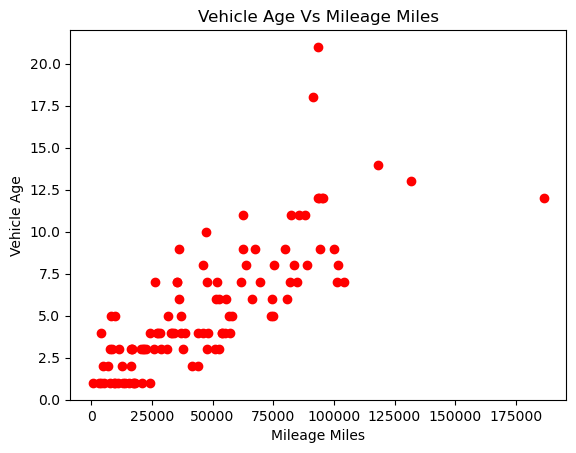

In [100]:
plt.scatter(x=df['Mileage_Miles'],y=df['Vehicle_Age'],color='red')
plt.title('Vehicle Age Vs Mileage Miles')
plt.xlabel('Mileage Miles')
plt.ylabel('Vehicle Age')
plt.show()
#There are outliers as shown on the graph

<Axes: >

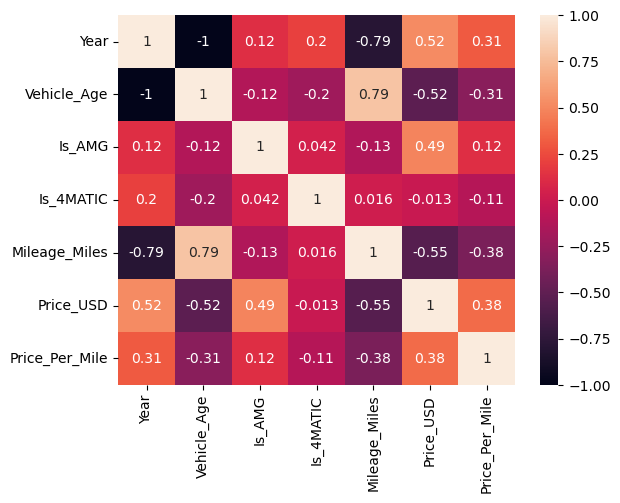

In [101]:
sns.heatmap(corr_value,annot=True)

In [8]:
df2=df.drop(labels={'Body_Type','Model_Series','Mileage_Category',
                           'Model_Series','Trim_Level','Price_Category'},axis=1)
df2

,Year,Vehicle_Age,Is_AMG,Is_4MATIC,Mileage_Miles,Price_USD,Price_Per_Mile
Vehicle_Name,,,,,,,
2021 Mercedes-Benz AMG G 63 Base,2021,5,1,0,9938,169995,17.105554
2025 Mercedes-Benz AMG S 63 E 4MATIC,2025,1,1,1,9860,151900,15.405680
2024 Mercedes-Benz AMG GT 55 Base,2024,2,1,0,6937,122881,17.713853
2020 Mercedes-Benz AMG S 65 Base,2020,6,1,0,52802,114995,2.177853
2019 Mercedes-Benz AMG G 63 4MATIC,2019,7,1,1,61559,111990,1.819230
...,...,...,...,...,...,...,...
2014 Mercedes-Benz GLK-Class GLK 350 4MATIC,2014,12,0,1,93434,10996,0.117687
2014 Mercedes-Benz M-Class 4MATIC,2014,12,0,1,94061,10994,0.116882
2014 Mercedes-Benz E-Class E 250 BlueTEC 4MATIC,2014,12,0,1,186500,9650,0.051743


In [103]:
col_skew=df2.skew()
col_skew
#skewness above 1 is heavily skew

Year             -1.276351
Vehicle_Age       1.276351
Is_AMG            2.117900
Is_4MATIC        -0.808728
Mileage_Miles     0.962811
Price_USD         2.096824
Price_Per_Mile    7.191367
dtype: float64

In [9]:
#To correct heavily skew columns
skew_values = df2.skew()

for col, skew_val in skew_values.items():
    if skew_val > 1:
        new_val = np.log1p(skew_val)
        print(col, new_val)

Vehicle_Age 0.8225735907954405
Is_AMG 1.1371596198458684
Price_USD 1.1303770881123978
Price_Per_Mile 2.103080751522988


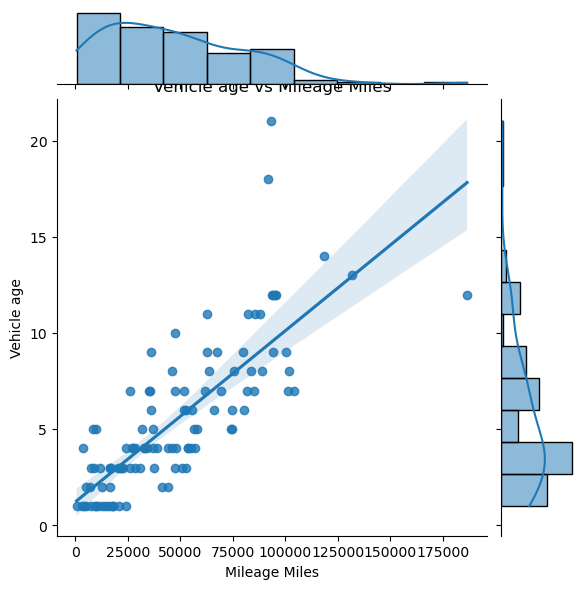

In [105]:
#scatterplot of vehicle age and Mileage miles
sns.jointplot(x='Mileage_Miles',y='Vehicle_Age',data=n_col,kind='reg')
plt.xlabel('Mileage Miles')
plt.ylabel('Vehicle age')
plt.title('Vehicle age vs Mileage Miles')
plt.show()

#identify outliers in n_col(numerated columns)
n_col.describe()
#There are outliers in Mileage_Miles 

In [ ]:

num_cols = df2.select_dtypes(include='number').columns
for col in num_cols:
    Q1 = df2[col].quantile(0.25)
    Q3 = df2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df2[col] = df2[col].clip(lower, upper)
df2.describe()


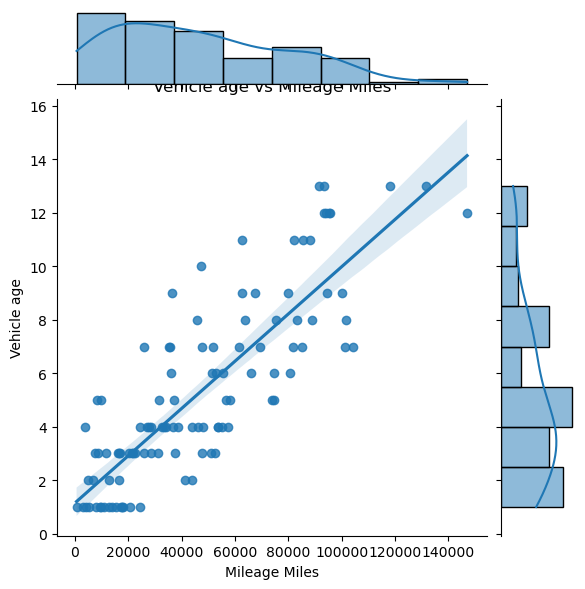

In [59]:
#Outliers has been removed 
sns.jointplot(x='Mileage_Miles',y='Vehicle_Age',data=df2,kind='reg')
plt.xlabel('Mileage Miles')
plt.ylabel('Vehicle age')
plt.title('Vehicle age vs Mileage Miles')
plt.show()

pip install numpy pandas matplotlib seaborn scikit-learn

In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score


In [121]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score


x=df2.drop(columns='Price_USD',axis=1)
y=df2['Price_USD']

#train test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
# model selection
model=LinearRegression()
#train model
model.fit(x_train,y_train)
#predict
y_pred=model.predict(x_test)
print(y_pred)

print('MAE:', mean_absolute_error(y_test,y_pred))
print('r2 Score:', r2_score(y_test,y_pred))

[52352.41427556 48196.88072928 57597.187194   31711.74101336
 51097.60788035 41123.80040422 35949.41427735 49642.08798117
 17879.38812915 51901.72822668 30483.97277895 13863.42770563
 75961.53397861 31405.86167859 77755.77088275 32818.0847184
 33629.98820993 28792.04942836   524.81776288 45649.84184772
 45200.26510535 40564.56136895]
MAE: 17373.672403625806
r2 Score: 0.45215325921283445


In [122]:
print("Train R2:", model.score(x_train, y_train))
print("Test R2:", model.score(x_test, y_test))

Train R2: 0.5275311981268835
Test R2: 0.45215325921283445


In [123]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("RF R2:", r2_score(y_test, y_pred_rf))
print("RF MAE:", mean_absolute_error(y_test, y_pred_rf))

RF R2: 0.8612423654747364
RF MAE: 8325.18409090909


In [124]:
print("RF Train R2:", rf.score(x_train, y_train))
print("RF Test R2:", rf.score(x_test, y_test))
#Using the RandomForestRegressor gave us a much better train and test R2, which indicates an excellent model 
#compared to using LinearRegression method


RF Train R2: 0.9505320048068616
RF Test R2: 0.8612423654747364


In [12]:
df.to_csv('mercedes1.csv')

In [13]:
df.head()

,Vehicle_Name,Year,Vehicle_Age,Model_Series,Trim_Level,Body_Type,Is_AMG,Is_4MATIC,Mileage_Miles,Mileage_Category,Price_USD,Price_Category,Price_Per_Mile
0,2025 Mercedes-Benz AMG S 63 E 4MATIC,2025,1,AMG S 63,S 63,Other,1,1,9860,Low (< 20K),151900,Luxury (> $70K),15.405680
1,2025 Mercedes-Benz GLE 580 4MATIC,2025,1,GLE,E 580,SUV,0,1,3154,Low (< 20K),82975,Luxury (> $70K),26.307863
2,2025 Mercedes-Benz GLS 450 4MATIC,2025,1,GLS,S 450,SUV,0,1,15496,Low (< 20K),75500,Luxury (> $70K),4.872225
3,2025 Mercedes-Benz GLE 450e 4MATIC,2025,1,GLE,E 450,SUV,0,1,9303,Low (< 20K),67996,Premium ($40K-$70K),7.309040
4,2025 Mercedes-Benz GLE 450e 4MATIC,2025,1,GLE,E 450,SUV,0,1,17259,Low (< 20K),63928,Premium ($40K-$70K),3.704038


In [52]:
 df.Vehicle_Age.value_counts()
   
    


Vehicle_Age
4     17
3     17
1     16
7     11
5      8
6      7
2      6
8      6
9      6
12     5
11     4
10     1
13     1
14     1
18     1
21     1
Name: count, dtype: int64